In [77]:
import pyreadstat
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

df, meta = pyreadstat.read_sav('/home/vs428/project/Uncertainty_data/BRUSH NEW DATA with neg test data reversed.sav')


In [78]:
display(df.head())
print(meta.column_names)
print(meta.column_labels)
print(meta.column_names_to_labels)
print(meta.number_rows)
print(meta.number_columns)
print(meta.file_label)
print(meta.file_encoding)
# # there are other metadata pieces extracted. See the documentation for more details.

,CONDITION,School,id,TimehrsSession2Session1,I01,CHF01testL,CHF01btestL,posneg1,Sens1,Spec1,...,Dem13Time,Condition2,V281,V282,V283,V284,TotalTimemin18minvideoand3cases,@18min.Videotimeonlymin,V287,V288
0,1.0,McMaster,1.0,90.008056,NaN,65.0,60.0,NEG,54.0,96.0,...,13.12,1.0,NaN,NaN,NaN,(1) Video Condition,62.681500,50.351667,NaN,NaN
1,1.0,McMaster,2.0,29.465000,NaN,10.0,7.0,,54.0,96.0,...,9.78,1.0,NaN,NaN,NaN,,14.570667,8.759667,NaN,NaN
2,1.0,McMaster,3.0,41.366389,NaN,5.0,2.0,,54.0,96.0,...,12.83,1.0,NaN,NaN,NaN,,14.522167,7.594833,NaN,NaN
3,1.0,EVMS,4.0,52.859167,NaN,10.0,4.0,,54.0,96.0,...,10.49,1.0,NaN,NaN,NaN,,5.430167,0.286167,NaN,NaN
4,1.0,McMaster,5.0,40.043889,NaN,2.0,1.0,,54.0,96.0,...,12.98,1.0,NaN,NaN,NaN,,29.793000,20.782333,NaN,NaN


['CONDITION', 'School', 'id', 'TimehrsSession2Session1', 'I01', 'CHF01testL', 'CHF01btestL', 'posneg1', 'Sens1', 'Spec1', 'Bayes1', 'Diff1', 'diff1sq', 'Err1', 'ES1', 'CHF02testM', 'CHF02btestM', 'posneg2', 'Sens2', 'Spec2', 'Bayes2', 'Diff2', 'Diff2sq', 'Err2', 'ES2', 'CHF03testH', 'CHF03btestH', 'posneg3', 'Sens3', 'Spec3', 'Bayes3', 'Diff3', 'Diff3sq', 'Err3', 'ES3', 'CHF04testM', 'CHF04btestM', 'posneg4', 'Sens4', 'Spec4', 'Bayes4', 'Diff4', 'Diff4sq', 'Err4', 'ES4', 'Pye05testF', 'Pye05btestF', 'posneg5', 'Sens5', 'Spec5', 'Bayes5', 'Diff5', 'Err5', 'ES5', 'Cry06testF', 'Cry06btestF', 'posneg6', 'Sens6', 'Spec6', 'Bayes6', 'Diff6', 'Err6', 'ES6', 'PEm07testM', 'PEm07btestM', 'posneg7', 'Sens7', 'Spec7', 'Bayes7', 'Diff7', 'Diff7sq', 'Err7', 'ES7', 'PEm08testH', 'PEm08btestH', 'posneg8', 'Sens8', 'Spec8', 'Bayes8', 'Diff8', 'Diff8sq', 'Err8', 'ES8', 'PEm09testM', 'PEm09btestM', 'posneg9', 'Sens9', 'Spec9', 'Bayes9', 'Diff9', 'Diff9sq', 'Err9', 'ES9', 'PEm10testL', 'PEm10btestL', 'p

In [79]:
# we should probably run Pyelo, Cry, Chl, and SAH at some point too, but for now, we just stick with the 4 we have. 
# df.columns[df.columns.str.contains("|".join(['CHF', "Pye", 'Cry', 'PE',  'Chl', 'SAH', 'ACS', 'Pna'])) & ~df.columns.str.contains("Time")]

In [80]:
df.columns[df.columns.str.contains("|".join(['CHF',  'PE', 'ACS', 'Pna'])) & ~df.columns.str.contains("Time") & ~df.columns.str.contains("btest")]

Index(['CHF01testL', 'CHF02testM', 'CHF03testH', 'CHF04testM', 'PEm07testM',
       'PEm08testH', 'PEm09testM', 'PEm10testL', 'ACS13testH', 'ACS14testL',
       'ACS15testM', 'ACS16testM', 'Pna17testH', 'Pna18testM', 'Pna19testM',
       'Pna20testL'],
      dtype='object')

In [81]:
df.columns[df.columns.str.contains("|".join(['CHF',  'PE', 'ACS', 'Pna'])) & ~df.columns.str.contains("Time") & ~df.columns.str.contains(r"\ntest", regex=True)]

Index(['CHF01testL', 'CHF01btestL', 'CHF02testM', 'CHF02btestM', 'CHF03testH',
       'CHF03btestH', 'CHF04testM', 'CHF04btestM', 'PEm07testM', 'PEm07btestM',
       'PEm08testH', 'PEm08btestH', 'PEm09testM', 'PEm09btestM', 'PEm10testL',
       'PEm10btestL', 'ACS13testH', 'ACS13btestH', 'ACS14testL', 'ACS14btestL',
       'ACS15testM', 'ACS15btestM', 'ACS16testM', 'ACS16btestM', 'Pna17testH',
       'Pna17btestH', 'Pna18testM', 'Pna18btestM', 'Pna19testM', 'Pna19btestM',
       'Pna20testL', 'Pna20btestL'],
      dtype='object')

In [82]:
df.columns[df.columns.str.contains('11')]

Index(['Chl11testF', 'Chl11btestT', 'posneg11', 'Sens11', 'Spec11', 'Bayes11',
       'Diff11', 'Diff11sq', 'Err11', 'ES11', 'Chl11testFTime',
       'Chl11btestTTime'],
      dtype='object')

# Figure out which of all the cases we have Physician data for

In [83]:
import pandas as pd

In [84]:
data = pd.read_csv("/home/vs428/project/Uncertainty_data/all_cases.csv", sep="|",  engine="c")

In [85]:
data['case'] = data['case'].str.replace("“", '"')
data['case'] = data['case'].str.replace("”", '"')
data['case'] = data['case'].str.replace("’", "'")
data['case'] = data['case'].str.replace("½", "1/2")
data['case'] = data['case'].str.replace("–", "-")

In [86]:
for case in data['case'].tolist():
    try:
        case.encode('ascii')
    except UnicodeDecodeError:
        print("it was not a ascii-encoded unicode string")

In [87]:
# the rest we don't have data for, so we set them to 0
data['physician_estimates'] = 0

In [88]:
# Rows with both GPT and Physician estimates

# CHF-4: 13, 19, 24, 21
# Pye-1: 
# Cry-1: 
# PE-4: 35, 40, 34, 33
# Chl-1: 
# SAH-1: 
# ACS-4: 10, 2, 6, 8
# Pna-4: 29, 27, 28, 26

# the rows that we have physician data for (some of them were for training purposes for EXPERIENTIAL GROUP so we don't have data for them)
data.iloc[[13, 19, 24, 21],  data.columns.get_loc('physician_estimates')] = 1
data.iloc[[35, 40, 34, 33],  data.columns.get_loc('physician_estimates')] = 1
data.iloc[[10, 2, 6, 8],  data.columns.get_loc('physician_estimates')] = 1
data.iloc[[29, 27, 28, 26],  data.columns.get_loc('physician_estimates')] = 1

In [89]:
# for idx, case in enumerate(data['case']):
#     print(f"==================== Case Number: {idx} ====================")
#     print(case)
    

In [90]:
# 27 cases (9 for each condition) for experience group -> no data
# 16 cases (4 for 4 conditions) for test cases to compare against -> has data
data['physician_estimates'].value_counts()

physician_estimates
0    27
1    16
Name: count, dtype: int64

In [152]:
data[data['case_type'].isin(['ACS', "Pulmonary Embolism"])].shape[0] + 9

35

In [91]:
# with pd.option_context("display.max_colwidth", None):
#     display(data[data['physician_estimates'] == 0][['probability', "differential", "case"]])

# Clean Data

In [92]:
# drop the empty row
df = df[~df['id'].isna()]

In [93]:
# replace posneg values so they're all filled out
df[df.columns[df.columns.str.contains("posneg")]] = df[df.columns[df.columns.str.contains("posneg")]].replace(r'^\s*$', np.nan, regex=True).ffill(axis=0)

In [94]:
df['CONDITION'] = df['CONDITION'].replace(1, "CONCEPT") 
df['CONDITION'] = df['CONDITION'].replace(2, "EXPERIENCE") 
df['CONDITION'] = df['CONDITION'].replace(3, "CONTROL") 

## Reorganize physician estimate data

In [95]:
# this outputs both the condition, raw string IDs and a number for the next step
case_ids_of_interest = [(x[:-7], x[-7:-5], int(x[-7:-5])) for x in df.columns[df.columns.str.contains("|".join(['CHF',  'PE', 'ACS', 'Pna'])) & ~df.columns.str.contains("Time") & ~df.columns.str.contains("btest")].tolist()]

In [96]:
case_ids_of_interest

[('CHF', '01', 1),
 ('CHF', '02', 2),
 ('CHF', '03', 3),
 ('CHF', '04', 4),
 ('PEm', '07', 7),
 ('PEm', '08', 8),
 ('PEm', '09', 9),
 ('PEm', '10', 10),
 ('ACS', '13', 13),
 ('ACS', '14', 14),
 ('ACS', '15', 15),
 ('ACS', '16', 16),
 ('Pna', '17', 17),
 ('Pna', '18', 18),
 ('Pna', '19', 19),
 ('Pna', '20', 20)]

In [97]:
# df cols: case_type, case_num, pre, post, diff, posneg, probability
# diff doesn't seem to make any sense, so we dropped it
dfs = []
for case_type, string_id, idx in case_ids_of_interest:
    case_df = df[df.columns.intersection([f'{case_type}{string_id}testL', f'{case_type}{string_id}btestL', 
                f'{case_type}{string_id}testM', f'{case_type}{string_id}btestM',
                f'{case_type}{string_id}testH', f'{case_type}{string_id}btestH',
                f'posneg{idx}', 
                "CONDITION",
                # f"Diff{idx}",                                        
                # f'Sens{idx}', f'Spec{idx}', 
                # f'Bayes{idx}'
               ])]

    col_map = {case_df.columns[case_df.columns.str.contains(r"\dtest", regex=True)].tolist()[0]:"pretest_prob",
              case_df.columns[case_df.columns.str.contains(r"btest", regex=True)].tolist()[0]:"posttest_prob",
              f"posneg{idx}":"positive"}
    reform_df = case_df.rename(col_map, axis=1)
    reform_df['case_type'] = case_type
    reform_df['jbrush_case_num'] = idx
    reform_df['case_type'] = case_type
    reform_df['CONDITION'] = case_df['CONDITION']
    
    if case_df.columns[case_df.columns.str.contains(r"\dtest", regex=True)].tolist()[0][-1] == "H":
        prob = "high"
    elif case_df.columns[case_df.columns.str.contains(r"\dtest", regex=True)].tolist()[0][-1] == "M":
        prob = "medium"
    elif case_df.columns[case_df.columns.str.contains(r"\dtest", regex=True)].tolist()[0][-1] == "L":
        prob = "low"
    else:
        raise Exception(f"Weird prob: {case_df.columns[case_df.columns.str.contains(r"\dtest", regex=True)].tolist()[0]}")
    
    reform_df['probability'] = prob
    dfs.append(reform_df)

In [98]:
reformed_df = pd.concat(dfs, axis=0)

In [99]:
reformed_df['case_type'] = reformed_df['case_type'].replace("CHF", "CHF") 
reformed_df['case_type'] = reformed_df['case_type'].replace("PEm", "Pulmonary Embolism") 
reformed_df['case_type'] = reformed_df['case_type'].replace("ACS", "ACS") 
reformed_df['case_type'] = reformed_df['case_type'].replace("Pna", "PNEUMONIA") 

In [100]:
# provide the likelihood ratios for each case, whether it's positive or negative
for case in ['CHF', 'Pulmonary Embolism', 'ACS', 'PNEUMONIA']:
    reformed_df.loc[(reformed_df['case_type'] == case) & (reformed_df['positive'] == "POS"), "lr"] = data[data['physician_estimates'].astype(bool)].groupby("case_type").first().loc[case]['pos_lr']
    reformed_df.loc[(reformed_df['case_type'] == case) & (reformed_df['positive'] == "NEG"), "lr"] = data[data['physician_estimates'].astype(bool)].groupby("case_type").first().loc[case]['neg_lr']

## Compute True Bayesian Update scores

In [101]:
def compute_true_bayesian_update(pre_test, lr):
    if pre_test == 1:
        odds = ((pre_test)/(1-pre_test+ 0.000001)) * lr    
    else:
        odds = ((pre_test)/(1-pre_test)) * lr
    post_test = odds / (1 + odds)
    return post_test
    

In [102]:
reformed_df['true_posttest'] = reformed_df.apply(lambda row: compute_true_bayesian_update(row['pretest_prob'] / 100, row['lr']) * 100, axis=1)

In [103]:
reformed_df['bayes_diff'] = reformed_df['true_posttest'] - reformed_df['posttest_prob']

# Plot Physician Estimates By Condition

In [104]:
import seaborn as sns
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Physician Bayesian Estimation by Condition')

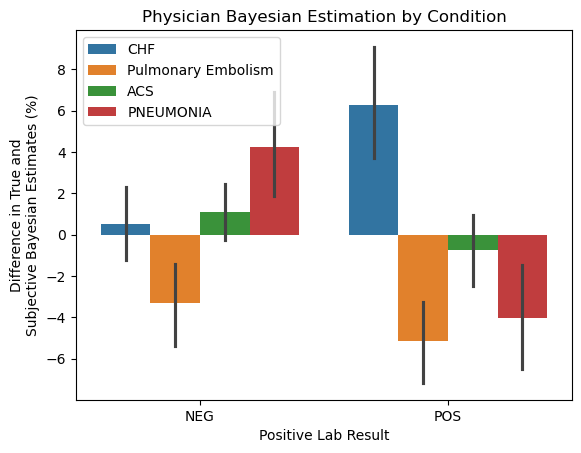

In [105]:
fig = sns.barplot(reformed_df, x="positive", y='bayes_diff', hue="case_type")
plt.ylabel("Difference in True and\nSubjective Bayesian Estimates (%)")
plt.xlabel("Positive Lab Result")
plt.legend( loc = 'upper left')
plt.title("Physician Bayesian Estimation by Condition")
# plt.savefig(f"physiciann_difference_by_condition.png", bbox_inches="tight")

Text(0.5, 1.0, 'GPT-4 Bayesian Estimation')

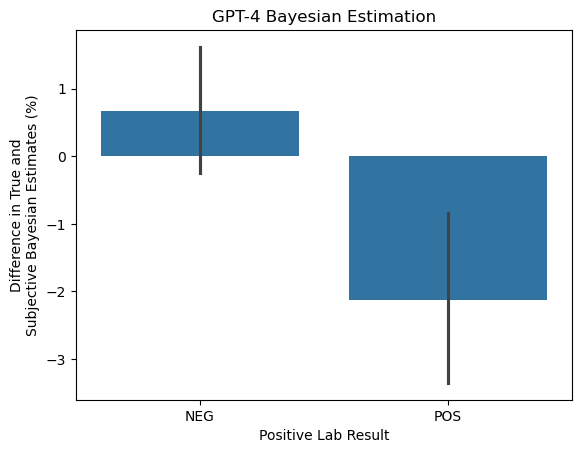

In [106]:
fig = sns.barplot(reformed_df, x="positive", y='bayes_diff')
plt.ylabel("Difference in True and\nSubjective Bayesian Estimates (%)")
plt.xlabel("Positive Lab Result")
plt.title("GPT-4 Bayesian Estimation")
# plt.savefig(f"physiciann_difference_by_condition.png", bbox_inches="tight")

Text(0.5, 1.0, 'Physician Bayesian Estimation by Treatment Arm')

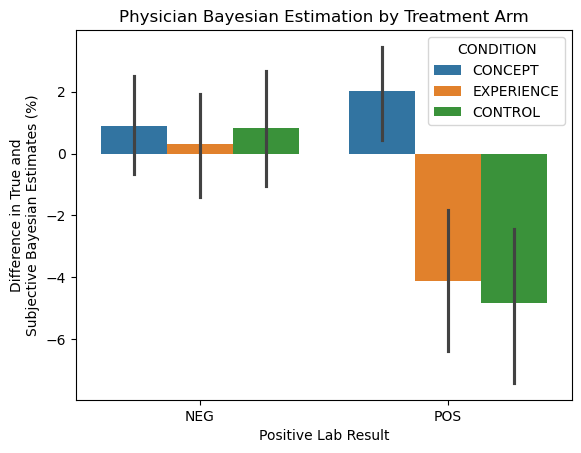

In [107]:
# Confirm the results from the paper
# The 
fig = sns.barplot(reformed_df, x="positive", y='bayes_diff', hue="CONDITION")
plt.ylabel("Difference in True and\nSubjective Bayesian Estimates (%)")
plt.xlabel("Positive Lab Result")
plt.title("Physician Bayesian Estimation by Treatment Arm")
# plt.savefig(f"physiciann_difference_by_condition.png", bbox_inches="tight")

# Combine with GPT-4 Results

In [108]:
data_with_gpt = pd.read_csv("output/all_cases_posneg_gpt4_output_3.csv")

In [109]:
data_with_gpt_noreasons = pd.read_csv("all_cases_posneg_gpt4_output_1no_reasoning.csv")

In [110]:
data_with_gpt_noLR = pd.read_csv("all_cases_posneg_gpt4_output_1_noLR.csv")

Text(0.5, 1.0, 'GPT-4 Bayesian Estimation')

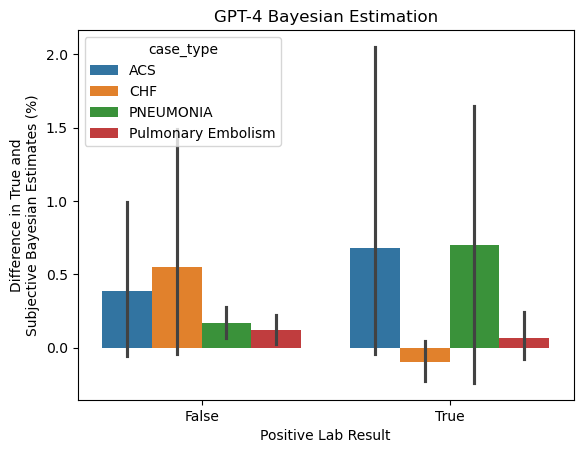

In [111]:
fig = sns.barplot(data_with_gpt, x="positive", y='bayes_diff', hue="case_type")
plt.ylabel("Difference in True and\nSubjective Bayesian Estimates (%)")
plt.xlabel("Positive Lab Result")
plt.title("GPT-4 Bayesian Estimation")
# plt.savefig(f"difference_by_condition_{version}.png", bbox_inches="tight")

# Plot Together

## Combine Physician and GPT-4

In [112]:
data_with_gpt['subject'] = "GPT-4"
# We didn't do anything to the GPT model so it's the control. Not exactly in the same way but similar
data_with_gpt['CONDITION'] = "CONTROL"
data_with_gpt['positive'] = np.where(data_with_gpt['positive'], "POS", "NEG")

In [113]:
data_with_gpt['positive'].value_counts()

positive
NEG    41
POS    37
Name: count, dtype: int64

In [114]:
data_with_gpt_noreasons['subject'] = "GPT-4"
# We didn't do anything to the GPT model so it's the control. Not exactly in the same way but similar
data_with_gpt_noreasons['CONDITION'] = "NO REASONING"
data_with_gpt_noreasons['positive'] = np.where(data_with_gpt_noreasons['positive'], "POS", "NEG")

In [115]:
data_with_gpt_noreasons['positive'].value_counts()

positive
NEG    41
POS    37
Name: count, dtype: int64

In [116]:
data_with_gpt_noLR['subject'] = "GPT-4"
# We didn't do anything to the GPT model so it's the control. Not exactly in the same way but similar
data_with_gpt_noLR['CONDITION'] = "NO LR"
data_with_gpt_noLR['positive'] = np.where(data_with_gpt_noLR['positive'], "POS", "NEG")

In [117]:
data_with_gpt.head(2)

,index,case_id,case_type,probability,differential,case,lab_value_text,q1,q2,pos_lr,neg_lr,pretest_prob,posttest_prob,pretest_llm_output,posttest_llm_output,true_posttest,positive,bayes_diff,subject,CONDITION
0,0,1,ACS,low,most likely anxiety,A 28 year-old woman presents to the ED with a ...,A troponin level was drawn and reported back f...,What is the probability that this patient has ...,Now what is the probability that this patient ...,4.75,0.25,5.0,20.0,The clinical presentation of the patient sugge...,With the new information regarding the abnorma...,20.0,POS,0.0,GPT-4,CONTROL
1,1,2,ACS,low,most likely pericarditis,A 35 year-old man presents to the ED with a 3-...,A troponin level was drawn and reported back f...,What is the probability that this patient has ...,Now what is the probability that this patient ...,4.75,0.25,5.0,20.0,To determine the likelihood that this 35-year-...,With the new information that the patient has ...,20.0,POS,0.0,GPT-4,CONTROL


In [118]:
reformed_df['subject'] = "Medical Students"; reformed_df.head(2)

,CONDITION,pretest_prob,posttest_prob,positive,case_type,jbrush_case_num,probability,lr,true_posttest,bayes_diff,subject
0,CONCEPT,65.0,60.0,NEG,CHF,1,low,0.48,47.129909,-12.870091,Medical Students
1,CONCEPT,10.0,7.0,NEG,CHF,1,low,0.48,5.063291,-1.936709,Medical Students


In [119]:
combined_df = pd.concat([data_with_gpt[["positive", 'bayes_diff', "case_type", "CONDITION", "subject"]], reformed_df[["positive", 'bayes_diff', "case_type", "CONDITION", "subject"]]], ignore_index=True)
combined_df_no_reason = pd.concat([data_with_gpt_noreasons[["positive", 'bayes_diff', "case_type", "CONDITION", "subject"]], reformed_df[["positive", 'bayes_diff', "case_type", "CONDITION", "subject"]]], ignore_index=True)
combined_df_noLR = pd.concat([data_with_gpt_noLR[["positive", 'bayes_diff', "case_type", "CONDITION", "subject"]], reformed_df[["positive", 'bayes_diff', "case_type", "CONDITION", "subject"]]], ignore_index=True)

In [120]:
import seaborn as sns
import matplotlib.pyplot as plt

In [121]:
combined_df['CONDITION'].value_counts()

CONDITION
CONTROL       382
CONCEPT       352
EXPERIENCE    320
Name: count, dtype: int64

In [122]:
# concept_combined_df = combined_df[((combined_df['CONDITION'] == "CONCEPT") & (combined_df['subject'] == "Medical Students")) | (combined_df['subject'] == "GPT-4") ]

In [123]:
from itertools import product

In [124]:
combined_df["subject-CONDITION"] = combined_df['subject'] + "-" + combined_df['CONDITION']
combined_df_no_reason["subject-CONDITION"] = combined_df_no_reason['subject'] + "-" + combined_df_no_reason['CONDITION']
combined_df_noLR["subject-CONDITION"] = combined_df_noLR['subject'] + "-" + combined_df_noLR['CONDITION']

[None, None, None, None]

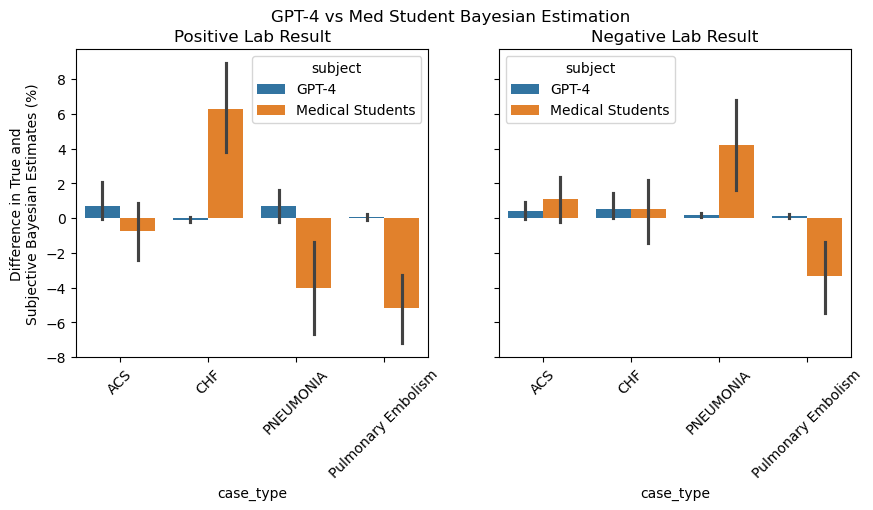

In [125]:
fig, axes = plt.subplots(1,2, figsize=(10,4), sharex=True, sharey=True,
                         # dpi=300
                        )
sns.barplot(combined_df[combined_df['positive'] == "POS"], x="case_type", y='bayes_diff', hue="subject", ax=axes[0])
axes[0].set_ylabel("Difference in True and\nSubjective Bayesian Estimates (%)")
# axes[1].set_xlabel("Condition")
# axes[1].set_xticks(rotation=70)
axes[0].set_title("Positive Lab Result")

sns.barplot(combined_df[combined_df['positive'] == "NEG"], x="case_type", y='bayes_diff', hue="subject", ax=axes[1])
axes[1].set_ylabel("Difference in True and\nSubjective Bayesian Estimates (%)")
# axes[1].set_xlabel("Condition")
# axes[1].set_xticks(rotation=70)
axes[1].set_title("Negative Lab Result")

fig.suptitle("GPT-4 vs Med Student Bayesian Estimation")
# axes[1].set_xlabel("Condition")
plt.setp( axes[0].xaxis.get_majorticklabels(), rotation=45 )
plt.setp( axes[1].xaxis.get_majorticklabels(), rotation=45 )

# plt.savefig(f"plots/comparisons/difference_by_condition.png", bbox_inches="tight")


[None, None, None, None]

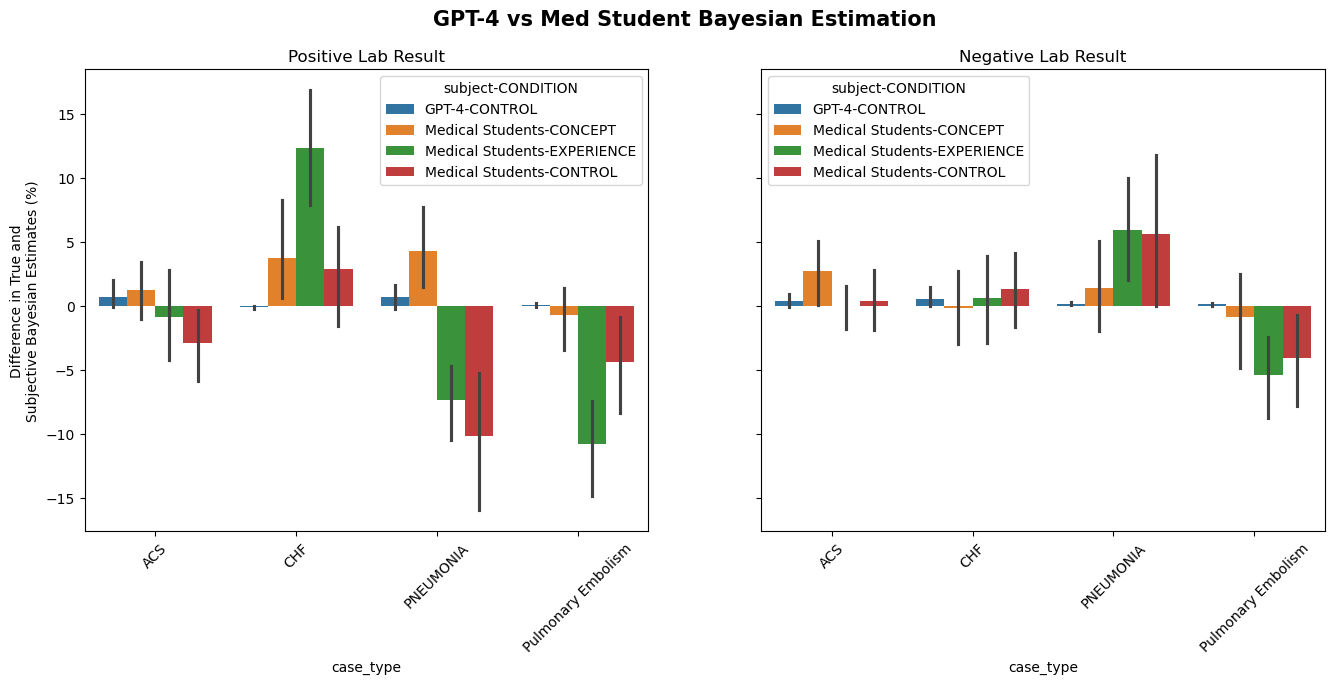

In [126]:
fig, axes = plt.subplots(1,2, figsize=(16,6), sharex=True, sharey=True,
                         # dpi=300
                        )
sns.barplot(combined_df[combined_df['positive'] == "POS"], x="case_type", y='bayes_diff', hue="subject-CONDITION", ax=axes[0])
axes[0].set_ylabel("Difference in True and\nSubjective Bayesian Estimates (%)")
axes[0].set_title("Positive Lab Result")

sns.barplot(combined_df[combined_df['positive'] == "NEG"], x="case_type", y='bayes_diff', hue="subject-CONDITION", ax=axes[1])
axes[1].set_ylabel("Difference in True and\nSubjective Bayesian Estimates (%)")
axes[1].set_title("Negative Lab Result")

fig.suptitle("GPT-4 vs Med Student Bayesian Estimation", size=15, weight="bold")
plt.setp( axes[0].xaxis.get_majorticklabels(), rotation=45 )
plt.setp( axes[1].xaxis.get_majorticklabels(), rotation=45 )

# plt.savefig(f"plots/comparisons/difference_by_condition_all_treatments.png", bbox_inches="tight")

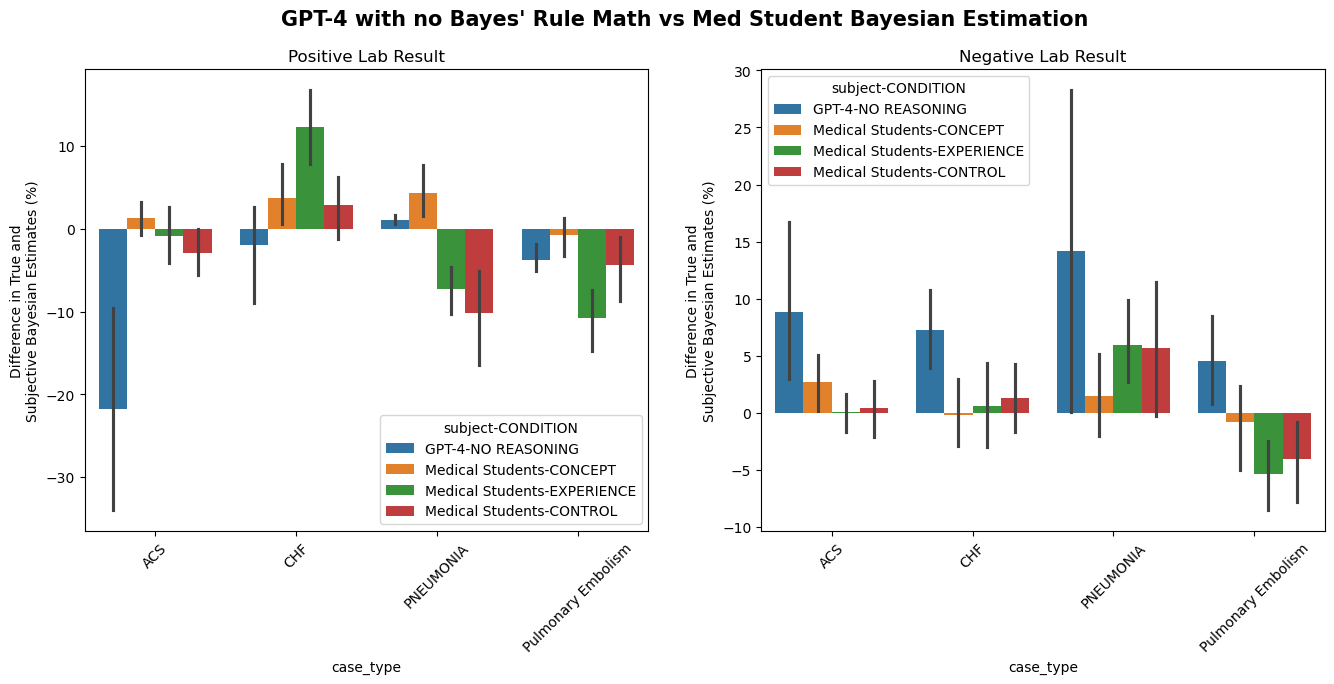

In [127]:
fig, axes = plt.subplots(1,2, figsize=(16,6), sharex=True, sharey=False,
                         # dpi=300
                        )
sns.barplot(combined_df_no_reason[combined_df_no_reason['positive'] == "POS"], x="case_type", y='bayes_diff', hue="subject-CONDITION", ax=axes[0])
axes[0].set_ylabel("Difference in True and\nSubjective Bayesian Estimates (%)")
axes[0].set_title("Positive Lab Result")

sns.barplot(combined_df_no_reason[combined_df_no_reason['positive'] == "NEG"], x="case_type", y='bayes_diff', hue="subject-CONDITION", ax=axes[1])
axes[1].set_ylabel("Difference in True and\nSubjective Bayesian Estimates (%)")
axes[1].set_title("Negative Lab Result")

fig.suptitle("GPT-4 with no Bayes' Rule Math vs Med Student Bayesian Estimation", size=15, weight="bold")
plt.setp( axes[0].xaxis.get_majorticklabels(), rotation=45 )
plt.setp( axes[1].xaxis.get_majorticklabels(), rotation=45 )

plt.savefig(f"plots/comparisons/difference_by_condition_all_treatments_nobayes.png", bbox_inches="tight")

# Gather all GPT Results with Physician Estimates

In [134]:
all_gpt_combined_df = pd.concat([combined_df, combined_df_no_reason, combined_df_noLR], axis=0)

In [143]:
data_with_gpt[(data_with_gpt['case_type'].isin(['ACS', "Pulmonary Embolism"])) & (data_with_gpt['positive'] == "NEG")].shape

(26, 20)

In [146]:
data_with_gpt[(data_with_gpt['positive'] == "NEG")].shape[0] + 9

50

In [135]:
all_gpt_combined_df = all_gpt_combined_df[all_gpt_combined_df['case_type'].isin(['ACS', "Pulmonary Embolism"])]

/tmp/ipykernel_1034486/2408532019.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(labels=['Acute Coronary\nSyndrome', "Pulmonary Embolism"])
/tmp/ipykernel_1034486/2408532019.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(labels=['Acute Coronary\nSyndrome', "Pulmonary Embolism"])


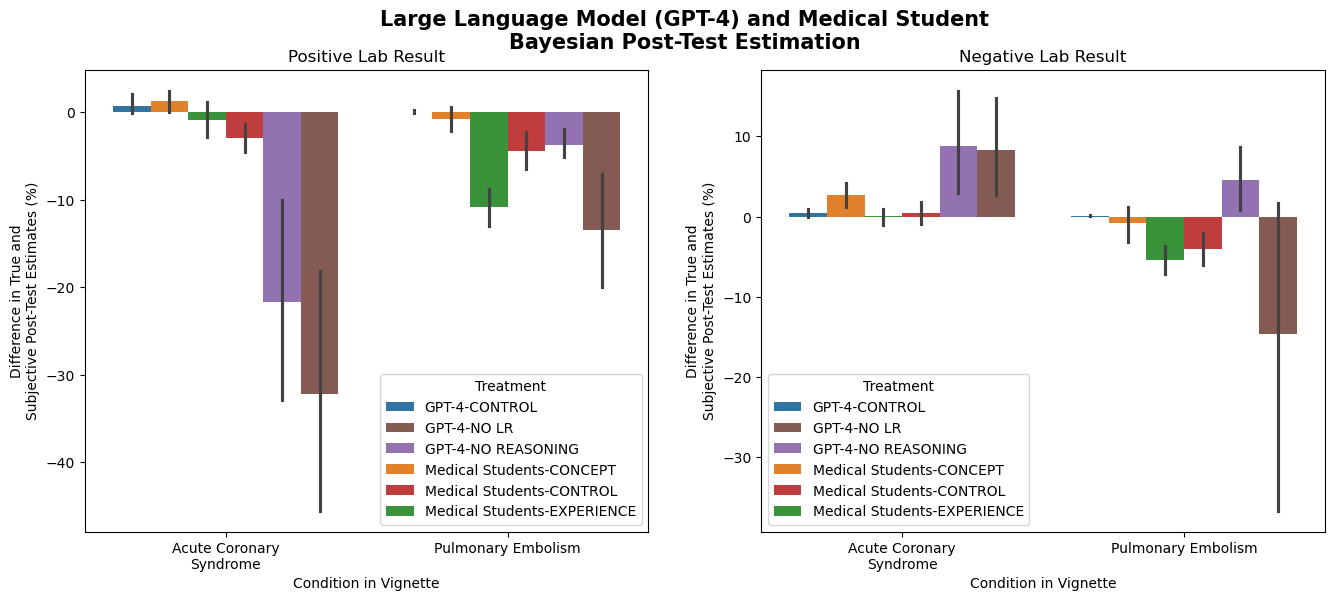

In [137]:
fig, axes = plt.subplots(1,2, figsize=(16,6), sharex=True, sharey=False,
                         # dpi=300
                        )


sns.barplot(all_gpt_combined_df[all_gpt_combined_df['positive'] == "POS"], x="case_type", y='bayes_diff', hue="subject-CONDITION", ax=axes[0])
axes[0].set_ylabel("Difference in True and\nSubjective Post-Test Estimates (%)")
axes[0].set_xlabel("Condition in Vignette")
axes[0].set_title("Positive Lab Result")
handles, labels = axes[0].get_legend_handles_labels()
# sort both labels and handles by labels
labels, handles = zip(*sorted(zip(labels, handles), key=lambda t: t[0]))
axes[0].legend(handles, labels, loc="lower right", title="Treatment")
axes[0].set_xticklabels(labels=['Acute Coronary\nSyndrome', "Pulmonary Embolism"])

sns.barplot(all_gpt_combined_df[all_gpt_combined_df['positive'] == "NEG"], x="case_type", y='bayes_diff', hue="subject-CONDITION", ax=axes[1])
axes[1].set_ylabel("Difference in True and\nSubjective Post-Test Estimates (%)")
axes[1].set_xlabel("Condition in Vignette")
axes[1].set_title("Negative Lab Result")
fig.suptitle("Large Language Model (GPT-4) and Medical Student\nBayesian Post-Test Estimation", size=15, weight="bold")
plt.setp( axes[0].xaxis.get_majorticklabels(), rotation=0 )
plt.setp( axes[1].xaxis.get_majorticklabels(), rotation=0 )
handles, labels = axes[1].get_legend_handles_labels()
# sort both labels and handles by labels
labels, handles = zip(*sorted(zip(labels, handles), key=lambda t: t[0]))
axes[1].legend(handles, labels, loc="lower left", title="Treatment")
axes[1].set_xticklabels(labels=['Acute Coronary\nSyndrome', "Pulmonary Embolism"])

plt.savefig(f"plots/comparisons/difference_by_condition_all_treatments_allgpt.png", bbox_inches="tight")

# Get numbers for SMDM Abstract

In [56]:
all_gpt_combined_df[all_gpt_combined_df['subject-CONDITION'] == "GPT-4-CONTROL"]['bayes_diff'].describe()

count    78.000000
mean      0.303100
std       1.247518
min      -0.448276
25%      -0.023232
50%       0.016431
75%       0.118577
max       8.724138
Name: bayes_diff, dtype: float64

In [58]:
# display(all_gpt_combined_df[all_gpt_combined_df['subject-CONDITION'] == "Medical Students-CONTROL"]['bayes_diff'].describe())
display(all_gpt_combined_df[all_gpt_combined_df['subject-CONDITION'] == "Medical Students-CONCEPT"]['bayes_diff'].describe())
display(all_gpt_combined_df[all_gpt_combined_df['subject-CONDITION'] == "Medical Students-EXPERIENCE"]['bayes_diff'].describe())

count    912.000000
mean      -1.285709
std       13.509273
min      -90.000000
25%       -5.235650
50%       -0.322581
75%        4.090909
max       61.538462
Name: bayes_diff, dtype: float64

count    1056.000000
mean        1.307146
std        10.937248
min       -53.740157
25%        -1.147104
50%         0.189726
75%         4.132012
max        49.999750
Name: bayes_diff, dtype: float64

count    960.000000
mean      -1.367442
std       12.354428
min      -50.000000
25%       -6.286107
50%       -0.322581
75%        4.124520
max       49.387755
Name: bayes_diff, dtype: float64

In [102]:
display(all_gpt_combined_df[all_gpt_combined_df['subject-CONDITION'] == "GPT-4-NO REASONING"]['bayes_diff'].describe())
display(all_gpt_combined_df[all_gpt_combined_df['subject-CONDITION'] == "GPT-4-NO LR"]['bayes_diff'].describe())

count    78.000000
mean     -0.550320
std      16.443200
min     -50.000000
25%      -2.867039
50%       0.563319
75%       4.859575
max      44.230769
Name: bayes_diff, dtype: float64

count    78.000000
mean     -6.530498
std      25.069134
min     -99.528549
25%      -8.783557
50%       0.298701
75%       3.718807
max      41.538462
Name: bayes_diff, dtype: float64

## Qualitative Eval: 

1. Correct
2. Correct
3. Incorrect application of formula: Post-test probability = Pre-test probability × LR-
4. Rounding: 0.731 (true) vs ~0.73 (GPT)
5. Correct
6. Rounding: 0.583 (true) vs ~0.58 (GPT)
7. Rounding: 0.17 (GPT) vs 0.174 (true)
8. Correct
9. Rounding: 0.73 (GPT) vs 0.731 (true)
10. Rounding:  0.671 (true) vs 0.67 (GPT)

In [66]:
pos_histories = pd.read_pickle("output/pos_chat_histories_3.pickle")
neg_histories = pd.read_pickle("output/neg_chat_histories_3.pickle")
histories = pos_histories + neg_histories

In [67]:
len(histories)

86

In [70]:
import random
sample = random.sample(histories, 10)

In [82]:
# pd.Series(sample).to_pickle("output/SMDM2024_qual_review_sample.pickle")

In [ ]:
for message in sample[9].messages:
    print("\n========================\n")
    print(message.content) 

# Compare Base Rates with Annotations



In [ ]:
# PE-4: 35, 40, 34, 33
# ACS-4: 10, 2, 6, 8
# Pna-4: 29, 27, 28, 26

In [103]:
import pandas as pd

In [156]:
combined__with_pretest_df = pd.concat([data_with_gpt[["positive", 'bayes_diff', "case_type", "CONDITION", "subject", "pretest_prob"]].rename({"pretest_prob":"gpt_pretest_prob"}, axis=1), reformed_df[["positive", 'bayes_diff', "case_type", "CONDITION", "subject", "pretest_prob"]].rename({"pretest_prob":"physician_pretest_prob"}, axis=1)], 
                                      
                                      ignore_index=True)
# combined_df_no_reason = pd.concat([data_with_gpt_noreasons[["positive", 'bayes_diff', "case_type", "CONDITION", "subject"]], reformed_df[["positive", 'bayes_diff', "case_type", "CONDITION", "subject"]]], ignore_index=True)
# combined_df_noLR = pd.concat([data_with_gpt_noLR[["positive", 'bayes_diff', "case_type", "CONDITION", "subject"]], reformed_df[["positive", 'bayes_diff', "case_type", "CONDITION", "subject"]]], ignore_index=True)

In [157]:
combined__with_pretest_df["subject-CONDITION"] = combined__with_pretest_df['subject'] + "-" + combined__with_pretest_df['CONDITION']
# combined_df_no_reason["subject-CONDITION"] = combined_df_no_reason['subject'] + "-" + combined_df_no_reason['CONDITION']
# combined_df_noLR["subject-CONDITION"] = combined_df_noLR['subject'] + "-" + combined_df_noLR['CONDITION']

In [159]:
combined__with_pretest_df.shape, data_with_gpt.shape, reformed_df.shape

((1054, 8), (78, 20), (976, 11))

## PE

In [226]:
reformed_df_pe = reformed_df[reformed_df['case_type'] == "Pulmonary Embolism"][['jbrush_case_num', "probability", "pretest_prob"]]

In [227]:
pe_anns = pd.read_csv('~/project/Uncertainty_data/annotations/Vignette_Score_Annotations-tth22-PE.csv')

In [228]:
pe_gpt = data_with_gpt[(data_with_gpt['case_type'] == "Pulmonary Embolism") & (data_with_gpt['positive'] == "NEG")][['index', "probability", "pretest_prob"]]

In [229]:
pe_anns_subset = pe_anns[['case_id',"case", "study_case_id", "Wells' Lower Bound Percent", "Wells' Upper Bound Percent"]]

In [230]:
pe_anns_gpt_bounds_df = pe_gpt.merge(pe_anns_subset, left_on="index", right_on="case_id")

In [249]:
reformed_df_pe.loc[reformed_df_pe['jbrush_case_num'] == 7, 'case_id'] = 35
reformed_df_pe.loc[reformed_df_pe['jbrush_case_num'] == 8, 'case_id'] = 40
reformed_df_pe.loc[reformed_df_pe['jbrush_case_num'] == 9, 'case_id'] = 34
reformed_df_pe.loc[reformed_df_pe['jbrush_case_num'] == 10, 'case_id'] = 33
reformed_df_pe_bounds_df = reformed_df_pe.merge(pe_anns_subset.set_index("case_id").loc[[35, 40, 34, 33]].reset_index(),
                                                on="case_id")

In [123]:
# gpt
pe_anns_gpt_bounds_df['out_of_bounds'] = np.where((pe_anns_gpt_bounds_df['pretest_prob'] > pe_anns_gpt_bounds_df["Wells' Lower Bound Percent"]) 
                                                  & (pe_anns_gpt_bounds_df['pretest_prob'] < pe_anns_gpt_bounds_df["Wells' Upper Bound Percent"]),
                                                  False, True)

In [251]:
# physicians
reformed_df_pe_bounds_df['out_of_bounds'] = np.where((reformed_df_pe_bounds_df['pretest_prob'] > reformed_df_pe_bounds_df["Wells' Lower Bound Percent"]) 
                                                  & (reformed_df_pe_bounds_df['pretest_prob'] < reformed_df_pe_bounds_df["Wells' Upper Bound Percent"]),
                                                  False, True)

In [185]:
pe_anns_gpt_bounds_df['out_of_bounds'].value_counts(normalize=True)

out_of_bounds
True     0.846154
False    0.153846
Name: proportion, dtype: float64

In [252]:
reformed_df_pe_bounds_df['out_of_bounds'].value_counts(normalize=True)

out_of_bounds
True     0.860656
False    0.139344
Name: proportion, dtype: float64

## ACS

In [256]:
reformed_df_acs = reformed_df[reformed_df['case_type'] == "ACS"][['jbrush_case_num', "probability", "pretest_prob"]]

In [257]:
acs_anns = pd.read_csv('/home/vs428/project/Uncertainty_data/annotations/Vignette_Score_Annotations-dw683-ACS.csv')

In [258]:
acs_gpt = data_with_gpt[(data_with_gpt['case_type'] == "ACS") & (data_with_gpt['positive'] == "NEG")][['index', "probability", "pretest_prob"]]

In [259]:
acs_anns_subset = acs_anns[['case_id', "study_case_id", "HEART Lower Bound Percent", "HEART Upper Bound Percent"]]

In [260]:
acs_anns_gpt_bounds_df = acs_gpt.merge(acs_anns_subset, left_on="index", right_on="case_id")

In [266]:
reformed_df_acs.loc[reformed_df_acs['jbrush_case_num'] == 13, 'case_id'] = 10
reformed_df_acs.loc[reformed_df_acs['jbrush_case_num'] == 14, 'case_id'] = 2
reformed_df_acs.loc[reformed_df_acs['jbrush_case_num'] == 15, 'case_id'] = 6
reformed_df_acs.loc[reformed_df_acs['jbrush_case_num'] == 16, 'case_id'] = 8
reformed_df_acs_bounds_df = reformed_df_acs.merge(acs_anns_subset.set_index("case_id").loc[[10, 2, 6, 8]].reset_index(),
                                                on="case_id")

In [267]:
reformed_df_acs_bounds_df.shape

(244, 7)

In [268]:
# gpt
acs_anns_gpt_bounds_df['out_of_bounds'] = np.where((acs_anns_gpt_bounds_df['pretest_prob'] > acs_anns_gpt_bounds_df["HEART Lower Bound Percent"]) 
                                                  & (acs_anns_gpt_bounds_df['pretest_prob'] < acs_anns_gpt_bounds_df["HEART Upper Bound Percent"]),
                                                  False, True)

In [269]:
# physicians
reformed_df_acs_bounds_df['out_of_bounds'] = np.where((reformed_df_acs_bounds_df['pretest_prob'] > reformed_df_acs_bounds_df["HEART Lower Bound Percent"]) 
                                                  & (reformed_df_acs_bounds_df['pretest_prob'] < reformed_df_acs_bounds_df["HEART Upper Bound Percent"]),
                                                  False, True)

In [270]:
acs_anns_gpt_bounds_df['out_of_bounds'].value_counts(normalize=True)

out_of_bounds
False    0.615385
True     0.384615
Name: proportion, dtype: float64

In [271]:
reformed_df_acs_bounds_df['out_of_bounds'].value_counts(normalize=True)

out_of_bounds
True     0.528689
False    0.471311
Name: proportion, dtype: float64

## Pneumonia

In [49]:
reformed_df_pneu = reformed_df[reformed_df['case_type'] == "PNEUMONIA"][['jbrush_case_num', "probability", "pretest_prob"]]

In [51]:
pneu_anns = pd.read_csv('/home/vs428/project/Uncertainty_data/annotations/Vignette_Score_Annotations-dw683-PNEUMONIA.csv')

In [56]:
pneu_anns = pneu_anns[pneu_anns['study'] == "JBrush"]

In [58]:
pneu_anns

,case_id,study_case_id,case_type,case,study,CURB-65 Lower Bound Points,CURB-65 Upper Bound Points,CURB-65 Lower Bound Percent,CURB-65 Upper Bound Percent,Notes
8,26,1,PNEUMONIA,A 23-year-old woman presents to the emergency ...,JBrush,0,1,0.6,2.7,[Confusion: 0] [BUN: 0-1] [RR: 0] [BP: 0] [Age...
9,27,2,PNEUMONIA,A 57-year-old man presents to the emergency de...,JBrush,0,1,0.6,2.7,[Confusion: 0] [BUN: 0-1] [RR: 0] [BP: 0] [Age...
10,28,3,PNEUMONIA,A 30-year-old man presents to the emergency de...,JBrush,0,1,0.6,2.7,[Confusion: 0] [BUN: 0-1] [RR: 0] [BP: 0] [Age...
11,29,4,PNEUMONIA,A 86-year-old woman is transferred to the emer...,JBrush,3,4,14.0,27.8,[Confusion: 1] [BUN: 0-1] [RR: 1] [BP: 0] [Age...


In [52]:
pneu_gpt = data_with_gpt[(data_with_gpt['case_type'] == "PNEUMONIA") & (data_with_gpt['positive'] == "NEG")][['index', "probability", "pretest_prob"]]

In [65]:
pneu_anns_subset = pneu_anns[['case_id', "study_case_id", "CURB-65 Lower Bound Percent", "CURB-65 Upper Bound Percent"]]

In [66]:
pneu_anns_gpt_bounds_df = pneu_gpt.merge(pneu_anns_subset, left_on="index", right_on="case_id")

In [67]:
reformed_df_pneu['jbrush_case_num'].value_counts()

jbrush_case_num
17    61
18    61
19    61
20    61
Name: count, dtype: int64

In [68]:
reformed_df_pneu.loc[reformed_df_pneu['jbrush_case_num'] == 17, 'case_id'] = 29
reformed_df_pneu.loc[reformed_df_pneu['jbrush_case_num'] == 18, 'case_id'] = 27
reformed_df_pneu.loc[reformed_df_pneu['jbrush_case_num'] == 19, 'case_id'] = 28
reformed_df_pneu.loc[reformed_df_pneu['jbrush_case_num'] == 20, 'case_id'] = 26
reformed_df_pneu_bounds_df = reformed_df_pneu.merge(pneu_anns_subset.set_index("case_id").loc[[29, 27, 28, 26]].reset_index(),
                                                on="case_id")

In [69]:
reformed_df_pneu_bounds_df.shape

(244, 7)

In [71]:
# gpt
pneu_anns_gpt_bounds_df['out_of_bounds'] = np.where((pneu_anns_gpt_bounds_df['pretest_prob'] > pneu_anns_gpt_bounds_df["CURB-65 Lower Bound Percent"]) 
                                                  & (pneu_anns_gpt_bounds_df['pretest_prob'] < pneu_anns_gpt_bounds_df["CURB-65 Upper Bound Percent"]),
                                                  False, True)

In [72]:
# physicians
reformed_df_pneu_bounds_df['out_of_bounds'] = np.where((reformed_df_pneu_bounds_df['pretest_prob'] > reformed_df_pneu_bounds_df["CURB-65 Lower Bound Percent"]) 
                                                  & (reformed_df_pneu_bounds_df['pretest_prob'] < reformed_df_pneu_bounds_df["CURB-65 Upper Bound Percent"]),
                                                  False, True)

In [75]:
pneu_anns_gpt_bounds_df

,index,probability,pretest_prob,case_id,study_case_id,CURB-65 Lower Bound Percent,CURB-65 Upper Bound Percent,out_of_bounds
0,26,low,5.0,26,1,0.6,2.7,True
1,27,medium,70.0,27,2,0.6,2.7,True


In [73]:
pneu_anns_gpt_bounds_df['out_of_bounds'].value_counts(normalize=True)

out_of_bounds
True    1.0
Name: proportion, dtype: float64

In [76]:
reformed_df_pneu_bounds_df

,jbrush_case_num,probability,pretest_prob,case_id,study_case_id,CURB-65 Lower Bound Percent,CURB-65 Upper Bound Percent,out_of_bounds
0,17,high,90.0,29.0,4,14.0,27.8,True
1,17,high,80.0,29.0,4,14.0,27.8,True
2,17,high,80.0,29.0,4,14.0,27.8,True
3,17,high,60.0,29.0,4,14.0,27.8,True
4,17,high,50.0,29.0,4,14.0,27.8,True
...,...,...,...,...,...,...,...,...
239,20,low,60.0,26.0,1,0.6,2.7,True
240,20,low,10.0,26.0,1,0.6,2.7,True
241,20,low,30.0,26.0,1,0.6,2.7,True
242,20,low,30.0,26.0,1,0.6,2.7,True


In [74]:
reformed_df_pneu_bounds_df['out_of_bounds'].value_counts(normalize=True)

out_of_bounds
True     0.991803
False    0.008197
Name: proportion, dtype: float64